---
---
## Dataset 1: Classification

The dataset, called FARS, is a collection of statistics of US road traffic accidents. The class label (target variable) is about the severity of the accident. It has 20 features and over 100K examples.


Importing and installing relevant libraries

In [ ]:
from scipy.stats import chi2_contingency, pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

The Dataset has 100968 rows and 30 coloumns. Let us analyse further

In [ ]:
#Fetching fars dataset and storing in Fetched_data variable
myData = pd.read_csv('fars.csv')
myData.shape

(100968, 30)

Loading the data set and checking the number of samples and features.

*   The dataset contains various features such as CASE_STATE, AGE, SEX and INJURY_SEVERITY. These features suggest that the dataset involves demographic and situational data.
*   The dataset also mostly contains categorical features these will likely need preprocessing for machine learning model.



In [ ]:
#Checking how the dataset looks like
myData.head()

,CASE_STATE,AGE,SEX,PERSON_TYPE,SEATING_POSITION,RESTRAINT_SYSTEM-USE,AIR_BAG_AVAILABILITY/DEPLOYMENT,EJECTION,EJECTION_PATH,EXTRICATION,...,DRUG_TEST_RESULTS_(2_of_3),DRUG_TEST_TYPE_(3_of_3),DRUG_TEST_RESULTS_(3_of_3),HISPANIC_ORIGIN,TAKEN_TO_HOSPITAL,RELATED_FACTOR_(1)-PERSON_LEVEL,RELATED_FACTOR_(2)-PERSON_LEVEL,RELATED_FACTOR_(3)-PERSON_LEVEL,RACE,INJURY_SEVERITY
0,Alabama,34,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Air_Bag_Available_but_Not_Deployed_for_this_Seat,Totally_Ejected,Unknown,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
1,Alabama,20,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Deployed_Air_Bag_from_Front,Totally_Ejected,Unknown,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
2,Alabama,43,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury
3,Alabama,38,Female,Passenger_of_a_Motor_Vehicle_in_Transport,Front_Seat_-_Right_Side,Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0,Not_Tested_for_Drugs,0,Not_a_Fatality_(Not_Applicable),Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_a_Fatality_(Not_Applicable),Incapaciting_Injury
4,Alabama,50,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Deployed_Air_Bag_from_Front,Not_Ejected,Not_Ejected/Not_Applicable,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury


As seen in the dataset overview, most of the features in the dataset are categorical, Except 5 features are numerical. The INJURY_SEVERITY (target) Column is categorical and has to be encoded for machine learning.

In [ ]:
#Checking how the dataset looks like
myData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100968 entries, 0 to 100967
Data columns (total 30 columns):
 #   Column                               Non-Null Count   Dtype 
---  ------                               --------------   ----- 
 0   CASE_STATE                           100968 non-null  object
 1   AGE                                  100968 non-null  int64 
 2   SEX                                  100968 non-null  object
 3   PERSON_TYPE                          100968 non-null  object
 4   SEATING_POSITION                     100968 non-null  object
 5   RESTRAINT_SYSTEM-USE                 100968 non-null  object
 6   AIR_BAG_AVAILABILITY/DEPLOYMENT      100968 non-null  object
 7   EJECTION                             100968 non-null  object
 8   EJECTION_PATH                        100968 non-null  object
 9   EXTRICATION                          100968 non-null  object
 10  NON_MOTORIST_LOCATION                100968 non-null  object
 11  POLICE_REPORTED_ALCOHOL_IN

The following code shows the general statistics for the numerical feature.

*   The AGE feature ranges from 0 to 99 years, with a mean of 37.1 it shows a wide age distribution.
*   For ALCOHOL_TEST_RESULT feature many has many values around 96.



In [ ]:
# Numerical stats
myData.describe()

,AGE,ALCOHOL_TEST_RESULT,DRUG_TEST_RESULTS_(1_of_3),DRUG_TEST_RESULTS_(2_of_3),DRUG_TEST_RESULTS_(3_of_3)
count,100968.000000,100968.000000,100968.000000,100968.000000,100968.000000
mean,37.106707,68.023116,207.393758,100.089672,95.441556
std,22.109641,42.306371,396.194002,295.089512,292.121277
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,15.000000,0.000000,0.000000,0.000000
50%,32.000000,96.000000,0.000000,0.000000,0.000000
75%,49.000000,96.000000,1.000000,0.000000,0.000000
max,99.000000,99.000000,999.000000,999.000000,999.000000


The dataset contains 7964 duplicated entries that should be removed.

In [ ]:
#Check for duplicate entries
myData.duplicated().sum()

7964

Check unqiue values for each coloumn in the dataset.

In [ ]:
#Unqiue values
unique_counts = myData.nunique()
print(unique_counts)

CASE_STATE                             51
AGE                                    99
SEX                                     3
PERSON_TYPE                            10
SEATING_POSITION                       26
RESTRAINT_SYSTEM-USE                   12
AIR_BAG_AVAILABILITY/DEPLOYMENT        13
EJECTION                                4
EJECTION_PATH                          10
EXTRICATION                             3
NON_MOTORIST_LOCATION                  18
POLICE_REPORTED_ALCOHOL_INVOLVEMENT     4
METHOD_ALCOHOL_DETERMINATION            7
ALCOHOL_TEST_TYPE                      10
ALCOHOL_TEST_RESULT                    69
POLICE-REPORTED_DRUG_INVOLVEMENT        4
METHOD_OF_DRUG_DETERMINATION            5
DRUG_TEST_TYPE_(1_of_3)                 7
DRUG_TEST_RESULTS_(1_of_3)             95
DRUG_TEST_TYPE_(2_of_3)                 7
DRUG_TEST_RESULTS_(2_of_3)             73
DRUG_TEST_TYPE_(3_of_3)                 7
DRUG_TEST_RESULTS_(3_of_3)             59
HISPANIC_ORIGIN                   

Create a copy of original dataset and removing duplicated entries to get a precise result.

In [ ]:
# Removed duplicated rows
original_data = myData.copy()
myData = myData.drop_duplicates()
myData.duplicated().sum()

0

Check to set if any of the columns contains missing values. No missing or Nan values found.

In [ ]:
# Check missing data
missing_counts = myData.isnull().sum()
print("Missing values per column:")
print(missing_counts)

Missing values per column:
CASE_STATE                             0
AGE                                    0
SEX                                    0
PERSON_TYPE                            0
SEATING_POSITION                       0
RESTRAINT_SYSTEM-USE                   0
AIR_BAG_AVAILABILITY/DEPLOYMENT        0
EJECTION                               0
EJECTION_PATH                          0
EXTRICATION                            0
NON_MOTORIST_LOCATION                  0
POLICE_REPORTED_ALCOHOL_INVOLVEMENT    0
METHOD_ALCOHOL_DETERMINATION           0
ALCOHOL_TEST_TYPE                      0
ALCOHOL_TEST_RESULT                    0
POLICE-REPORTED_DRUG_INVOLVEMENT       0
METHOD_OF_DRUG_DETERMINATION           0
DRUG_TEST_TYPE_(1_of_3)                0
DRUG_TEST_RESULTS_(1_of_3)             0
DRUG_TEST_TYPE_(2_of_3)                0
DRUG_TEST_RESULTS_(2_of_3)             0
DRUG_TEST_TYPE_(3_of_3)                0
DRUG_TEST_RESULTS_(3_of_3)             0
HISPANIC_ORIGIN               

Check the distrubution of target variable using histogram to find if we need the correct any class imbalance. As seen in the plot, there is a significant imbalance in the distribution of target variable. The Fatal_injury being the dominant class in the distribution. This imbalance should be handled with sampling technique to avoid model being biased towards the dominant class.

<ipython-input-10-bb8ff5923538>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=myData, x='INJURY_SEVERITY', palette='viridis')


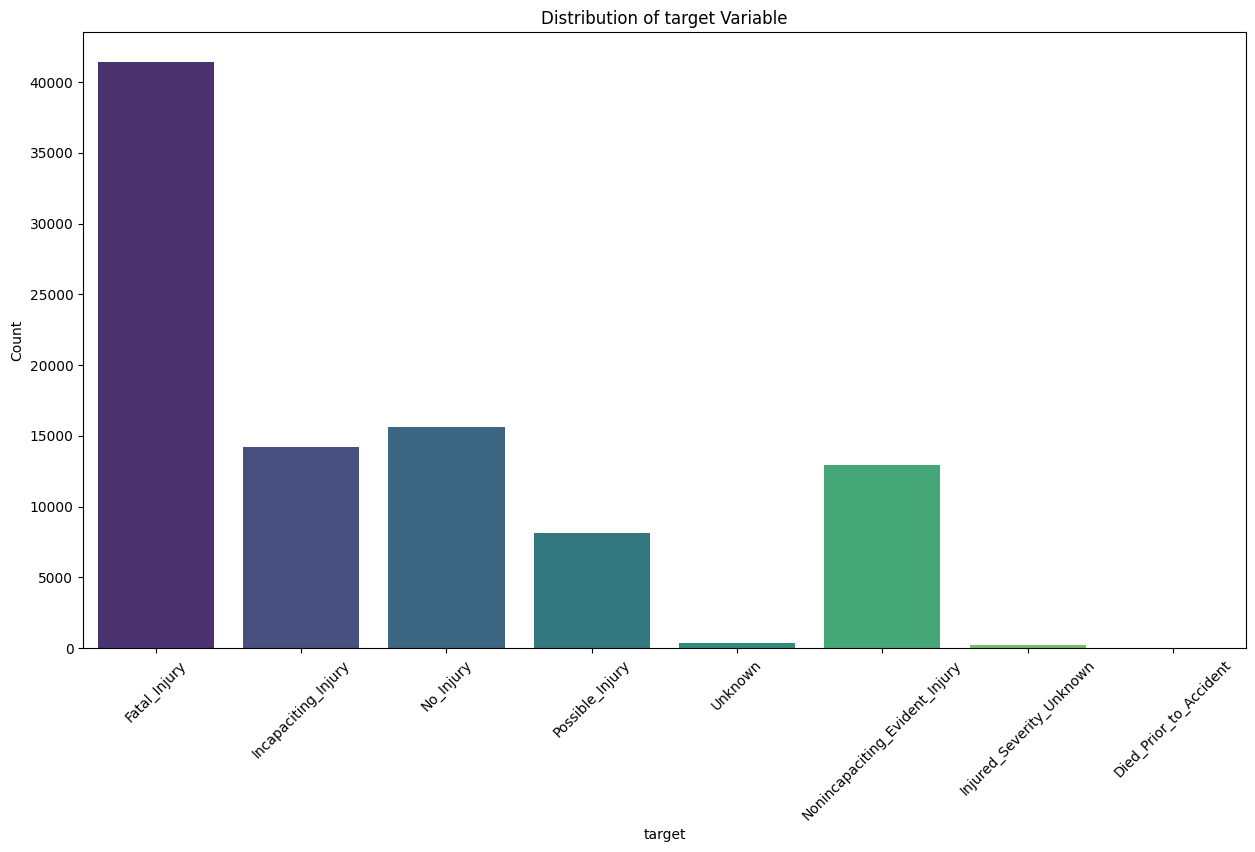

In [ ]:
# 1. Distribution of the Target Variable
plt.figure(figsize=(15, 8))
sns.countplot(data=myData, x='INJURY_SEVERITY', palette='viridis')
plt.title('Distribution of target Variable')
plt.xticks(rotation=45)
plt.xlabel('target')
plt.ylabel('Count')
plt.show()

Using boxplot for AGE feature vs INJURY_SEVERITY trying to find any corelation between the two variables. No significant outliers were detected.

<ipython-input-11-463fe30ecfcd>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=myData,x='INJURY_SEVERITY',y='AGE', palette='viridis')


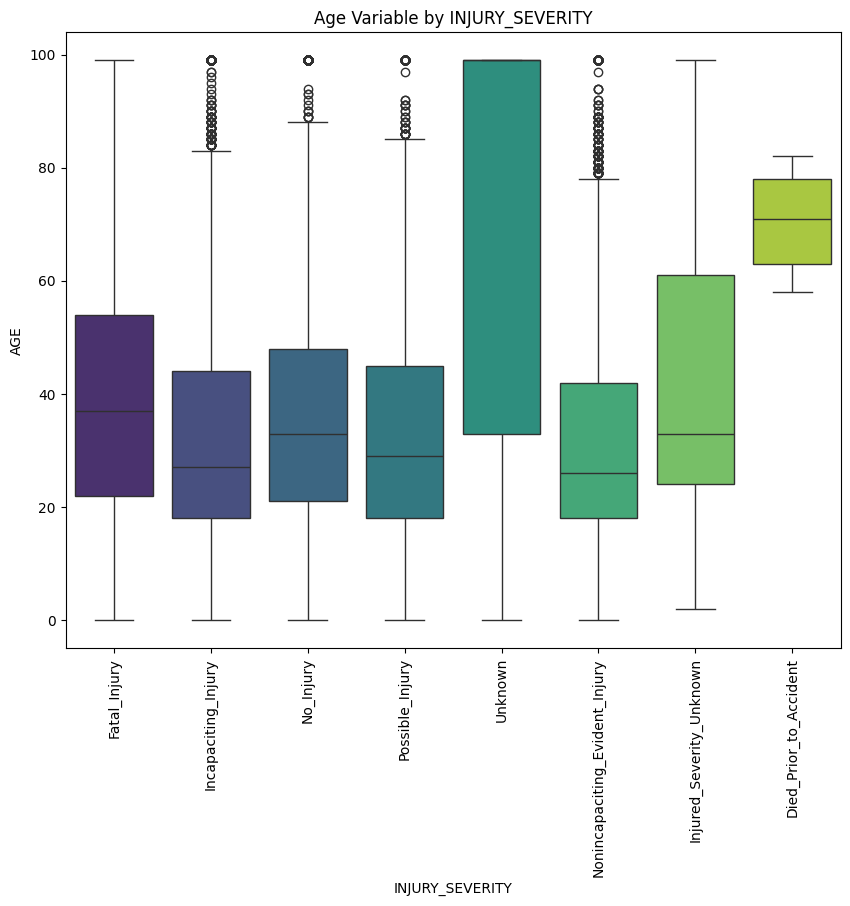

In [ ]:
#boxplots for age against injury_severity
plt.figure(figsize=(10, 8))
sns.boxplot(data=myData,x='INJURY_SEVERITY',y='AGE', palette='viridis')
plt.title('Age Variable by INJURY_SEVERITY')
plt.xlabel('INJURY_SEVERITY')
plt.xticks(rotation=90)
plt.ylabel('AGE')
plt.show()

Since the categorical variables are stored as integer, we need to dummy code in order to use the variables for training classification models

In [ ]:
# dummy coding with pandas
categorical_variables= ['CASE_STATE', 'SEX', 'PERSON_TYPE', 'SEATING_POSITION', 'RESTRAINT_SYSTEM-USE',
    'AIR_BAG_AVAILABILITY/DEPLOYMENT', 'EJECTION', 'EJECTION_PATH', 'EXTRICATION',
    'NON_MOTORIST_LOCATION', 'POLICE_REPORTED_ALCOHOL_INVOLVEMENT', 'METHOD_ALCOHOL_DETERMINATION',
    'ALCOHOL_TEST_TYPE', 'POLICE-REPORTED_DRUG_INVOLVEMENT',
    'METHOD_OF_DRUG_DETERMINATION', 'DRUG_TEST_TYPE_(1_of_3)',
    'DRUG_TEST_TYPE_(2_of_3)', 'DRUG_TEST_TYPE_(3_of_3)', 'HISPANIC_ORIGIN', 'TAKEN_TO_HOSPITAL',
    'RELATED_FACTOR_(1)-PERSON_LEVEL', 'RELATED_FACTOR_(2)-PERSON_LEVEL',
    'RELATED_FACTOR_(3)-PERSON_LEVEL', 'RACE']

myData_encoded = pd.get_dummies(myData, columns=categorical_variables, drop_first=True)
print(myData_encoded)
myData_encoded.dtypes

        AGE  ALCOHOL_TEST_RESULT  DRUG_TEST_RESULTS_(1_of_3)  \
0        34                   97                         999   
1        20                   96                           0   
2        43                   96                           0   
3        38                   96                           0   
4        50                   97                         999   
...     ...                  ...                         ...   
100963   10                   96                           0   
100964    9                   96                           0   
100965    7                   96                           0   
100966    4                   96                           0   
100967   61                   96                           0   

        DRUG_TEST_RESULTS_(2_of_3)  DRUG_TEST_RESULTS_(3_of_3)  \
0                                0                           0   
1                                0                           0   
2                                

,0
AGE,int64
ALCOHOL_TEST_RESULT,int64
DRUG_TEST_RESULTS_(1_of_3),int64
DRUG_TEST_RESULTS_(2_of_3),int64
DRUG_TEST_RESULTS_(3_of_3),int64
...,...
RACE_Other_Indian_(Includes_South_and_Central_America),bool
RACE_Samoan,bool
RACE_Unknown,bool
RACE_Vietnamese,bool


After performing dummy coding the number of features increases from 30 to 627 which makes the model training coputationaly expensive, hence to address this, we perform feature selection by droping features with very low variance as they are not very usefull in explaining the variability in the dataset. By keeping the varince threshold low at 0.1, we also ensure that there is minimal information leak. After the feature selection, we manage to bring the total features down from 627 to 113.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

X = myData_encoded.drop(columns=["INJURY_SEVERITY"])
y = myData_encoded["INJURY_SEVERITY"]

selector = VarianceThreshold(threshold=0.01)
reduced_data = selector.fit_transform(X)
print(reduced_data)

# Get the retained feature names
retained_columns = X.columns[selector.get_support()]

# Convert back to a DataFrame
reduced_data = pd.DataFrame(reduced_data, columns=retained_columns)
reduced_data = pd.concat([reduced_data, y.reset_index(drop=True)], axis=1)

reduced_data.shape

[[ 34  97 999 ...   0   0   1]
 [ 20  96   0 ...   0   0   1]
 [ 43  96   0 ...   0   0   0]
 ...
 [  7  96   0 ...   1   0   0]
 [  4  96   0 ...   1   0   0]
 [ 61  96   0 ...   0   0   1]]


(93004, 109)

Next, we split the data into 70% training set and 30% testing set.

In [ ]:
#Train test split
X = reduced_data.drop('INJURY_SEVERITY', axis=1)
y = reduced_data['INJURY_SEVERITY']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

Next, we perform oversampling since we discovered earlier that there was a huge imbalance in the target variable of the dataset. This ensure that the model we will train will provide equal importance to every class of target variable and reduce the possibility of overfitting.

In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE

smote = SMOTE()

# fit predictor and target variable
x_resampled, y_resampled = smote.fit_resample(X, y)

print('Dataset Before Resampling', Counter(y))
print('Dataset After Resampling', Counter(y_resampled))
print(type(y_resampled))

Dataset Before Resampling Counter({'Fatal_Injury': 41442, 'No_Injury': 15642, 'Incapaciting_Injury': 14230, 'Nonincapaciting_Evident_Injury': 12945, 'Possible_Injury': 8104, 'Unknown': 399, 'Injured_Severity_Unknown': 233, 'Died_Prior_to_Accident': 9})
Dataset After Resampling Counter({'Fatal_Injury': 41442, 'Incapaciting_Injury': 41442, 'No_Injury': 41442, 'Possible_Injury': 41442, 'Unknown': 41442, 'Nonincapaciting_Evident_Injury': 41442, 'Injured_Severity_Unknown': 41442, 'Died_Prior_to_Accident': 41442})
<class 'pandas.core.series.Series'>


Using a random value for neighbor which is 2. After traning the KNN model without any hypertuning, we found the traning f1 score to be 0.88 and testing f1 score to be 0.88 which can be considered as good performance and also tells us that there is no obvious overfitting or underfitting. Next we will train the KNN model by hypertuning the parameter which can improve the performance measure.

In [ ]:
#Train and test the KNN without hyper parameter tuning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Set up KNN classifier
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(x_resampled,y_resampled)
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
print(y_train_pred)
print(y_test_pred)
print("")
print("Training")
print(classification_report(y_train,y_train_pred))
print("")
print("Testing")
print(classification_report(y_test,y_test_pred))

['Nonincapaciting_Evident_Injury' 'Incapaciting_Injury' 'No_Injury' ...
 'Nonincapaciting_Evident_Injury' 'Fatal_Injury' 'Fatal_Injury']
['Incapaciting_Injury' 'Incapaciting_Injury' 'Fatal_Injury' ...
 'Possible_Injury' 'Fatal_Injury' 'Incapaciting_Injury']

Training
                                precision    recall  f1-score   support

        Died_Prior_to_Accident       0.24      1.00      0.38         8
                  Fatal_Injury       0.99      1.00      1.00     29005
           Incapaciting_Injury       0.69      0.99      0.81      9936
      Injured_Severity_Unknown       0.60      0.81      0.69       166
                     No_Injury       0.84      0.95      0.89     10967
Nonincapaciting_Evident_Injury       0.83      0.61      0.70      9095
               Possible_Injury       1.00      0.37      0.54      5653
                       Unknown       0.99      0.46      0.63       272

                      accuracy                           0.88     65102
          

To build the KNN model, we utilize grid search to find the optimal number of k which is 4.

In [ ]:
#Fitting models

#KNN with grid search
from sklearn.neighbors import KNeighborsClassifier
# Set up KNN classifier
knn = KNeighborsClassifier()


param_grid = {
    'n_neighbors': range(1, 8)
}

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_resampled, y_resampled)
print(f"Best number of neighbors (K): {grid_search.best_params_['n_neighbors']}")

Best number of neighbors (K): 4


We decided to select the k value as 4 as it performed the best using gridsearch method. After traning the KNN model, we found the traning f1 score to be 0.88 and testing f1 score to be 0.89 which can be considered as good performance and also tells us that there is no obvious overfitting or underfittinh. The high precison and recall values also shows that the KNN model is not just high in accuracy but can also predict different classes equally well.

In [ ]:
#Train and test the KNN after hyper parameter tuning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Set up KNN classifier
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(x_resampled,y_resampled)
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
print(y_train_pred)
print(y_test_pred)
print("")
print("Training")
print(classification_report(y_train,y_train_pred))
print("")
print("Testing")
print(classification_report(y_test,y_test_pred))

['Incapaciting_Injury' 'Nonincapaciting_Evident_Injury' 'No_Injury' ...
 'Nonincapaciting_Evident_Injury' 'Fatal_Injury' 'Fatal_Injury']
['Nonincapaciting_Evident_Injury' 'Incapaciting_Injury' 'Fatal_Injury' ...
 'Possible_Injury' 'Fatal_Injury' 'Incapaciting_Injury']

Training
                                precision    recall  f1-score   support

        Died_Prior_to_Accident       0.06      0.62      0.12         8
                  Fatal_Injury       0.99      0.98      0.99     29005
           Incapaciting_Injury       0.78      0.86      0.81      9936
      Injured_Severity_Unknown       0.35      0.78      0.49       166
                     No_Injury       0.90      0.91      0.91     10967
Nonincapaciting_Evident_Injury       0.80      0.72      0.76      9095
               Possible_Injury       0.71      0.68      0.69      5653
                       Unknown       0.53      0.82      0.64       272

                      accuracy                           0.89     65102

After training the decison tree model without hyper parameter tuning, we found the traning f1 score to be 0.96 and testing f1 score to be 0.96 which can be considered as good performance. However, the default parameters uses large maximum depth, minimum leafs and sample split which makes the tree weak in generalization for unseen dataset.

In [ ]:
# Decision tree without hyper parameter tuning
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Decision Tree Classifier model
decision_tree = DecisionTreeClassifier(random_state=42)

# model fit
decision_tree.fit(x_resampled, y_resampled)

# Predict on the train and test set
y_train_pred = decision_tree.predict(X_train)
y_test_pred = decision_tree.predict(X_test)

# Performance metrics overall

# Accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")


# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print(f"Confusion Matrix:\n{conf_matrix}")

# Classification Report
class_report = classification_report(y_test, y_test_pred)
print(f"Classification Report:\n{class_report}")


Training Accuracy: 0.96
Testing Accuracy: 0.96
Confusion Matrix:
[[    1     0     0     0     0     0     0     0]
 [    0 12437     0     0     0     0     0     0]
 [    0     0  4093     4     0   128    69     0]
 [    0     0     2    62     1     2     0     0]
 [    0     0     7     0  4545    20    88    15]
 [    0     0   275     9    23  3458    85     0]
 [    0     0   111     2   117   181  2040     0]
 [    0     0     0     0     9     2     0   116]]
Classification Report:
                                precision    recall  f1-score   support

        Died_Prior_to_Accident       1.00      1.00      1.00         1
                  Fatal_Injury       1.00      1.00      1.00     12437
           Incapaciting_Injury       0.91      0.95      0.93      4294
      Injured_Severity_Unknown       0.81      0.93      0.86        67
                     No_Injury       0.97      0.97      0.97      4675
Nonincapaciting_Evident_Injury       0.91      0.90      0.91      385

Next, we fit decision tree with hyper parameter tuning and find training and testing accuracy to be 0.84.

In [ ]:
#Decision tree with hyper parameter tuning

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Define the parameter grid for RandomizedSearchCV
param_distributions = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [None] + list(np.arange(5, 51, 5)),
    'min_samples_split': np.arange(2, 21, 2),
    'min_samples_leaf': np.arange(1, 21, 2),
    'max_features': [None, 'sqrt', 'log2']
}

# Initialize the Decision Tree Classifier
decision_tree = DecisionTreeClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=decision_tree,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings sampled
    cv=3,       # Cross-validation splits
    scoring='accuracy',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit RandomizedSearchCV to the data
random_search.fit(x_resampled, y_resampled)

# Output the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Cross-Validation Score: {random_search.best_score_:.2f}")

# Use the best model from RandomizedSearchCV
best_decision_tree = random_search.best_estimator_

# Predict on the train and test sets
y_train_pred = best_decision_tree.predict(X_train)
y_test_pred = best_decision_tree.predict(X_test)

# Performance evaluation
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print(f"Confusion Matrix:\n{conf_matrix}")

# Classification Report
class_report = classification_report(y_test, y_test_pred)
print(f"Classification Report:\n{class_report}")


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'splitter': 'best', 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 30, 'criterion': 'log_loss'}
Best Cross-Validation Score: 0.81
Training Accuracy: 0.84
Testing Accuracy: 0.84
Confusion Matrix:
[[    0     0     0     0     0     1     0     0]
 [    0 12433     1     0     0     0     0     3]
 [    0     0  3103    16     5   826   341     3]
 [    0     0    10    35     2    11     9     0]
 [    0     0    10     7  4178    74   342    64]
 [    0     0   853    28    91  2442   430     6]
 [    0     0   344    16   343   477  1265     6]
 [    0     0     1     0    19     9     6    92]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
                                precision    recall  f1-score   support

        Died_Prior_to_Accident       0.00      0.00      0.00         1
                  Fatal_Injury       1.00      1.00      1.00     12437
           Incapaciting_Injury       0.72      0.72      0.72      4294
      Injured_Severity_Unknown       0.34      0.52      0.41        67
                     No_Injury       0.90      0.89      0.90      4675
Nonincapaciting_Evident_Injury       0.64      0.63      0.64      3850
               Possible_Injury       0.53      0.52      0.52      2451
                       Unknown       0.53      0.72      0.61       127

                      accuracy                           0.84     27902
                     macro avg       0.58      0.63      0.60     27902
                  weighted avg       0.84      0.84      0.84     27902



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Conclusion :

To decide the best model to perform classification of injury severity, we considered f1 score, precall and precision. For both models, we did not encounter any underfitting or overfitting as the training and test perfomance measured were close to each other. Eventually, it makes sense for us to select the KNN with hypertuning as our best model since it provided the best performance measures. Decision tree with and without hyper parameter tuning provided pretty good accuracies as well but we used larger tree and higher number of leaf nodes which can lead to overfitting.

---
---
## Dataset 2: Regression

The provided dataset contains results from a set of experiments where we grew bacteria of different strains and under different conditions (CO2 availability, light, etc..) to compute a growth curve for the bacteria - represented by the variables 'a' and 'mu'. The goal is to predict the results of the experiment - 'a' and 'mu'.

The CSV contains 7 fields as follows:

| variable | description |
|-----|------|
| n_cyanos | The number of Cyanobacteria available at the start |
| co2 | The amount of CO2 available |
| light | The amount of light available |
| SucRatio | How good the bacteria is at producing sucrose |
| Nsample | Experiment number |
| a | Maximum number of bacteria seen (Target variable) |
| mu | Growth rate of bacteria (Target variable) |



Importing and installing relevant libraries

In [ ]:
import pandas as pd
from statsmodels.stats.anova import anova_lm
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

The dataset contains 19992 rows and 7 columns.

In [ ]:
df = pd.read_csv('/content/fitting-results2.csv')
df.shape

(19992, 7)

Loading the data set and checking the number of samples and number of features.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19992 entries, 0 to 19991
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   n_cyanos  19992 non-null  int64  
 1   co2       19992 non-null  float64
 2   light     19992 non-null  float64
 3   SucRatio  19992 non-null  float64
 4   Nsample   19992 non-null  int64  
 5   a         19992 non-null  float64
 6   mu        19992 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 1.1 MB


checking for duplicates and missing samples in dataset. None found

In [ ]:
#Check for duplicate entries
df.duplicated().sum()
df.isnull().sum()

,0
n_cyanos,0
co2,0
light,0
SucRatio,0
Nsample,0
a,0
mu,0


Most of the feature's show balanced distribution, spanning over entire range. The target variables a and mu show extreme maximum value, which suggests potential outliers.

In [ ]:
df.describe()

,n_cyanos,co2,light,SucRatio,Nsample,a,mu
count,19992.000000,19992.000000,19992.000000,19992.000000,19992.000000,19992.000000,19992.000000
mean,494.367547,49.890457,0.495162,0.496075,9997.371349,5.490172,5.634110
std,288.957886,29.138328,0.289767,0.289731,5772.058433,13.441047,9.862259
min,2.000000,0.001000,0.000001,0.000000,1.000000,0.000004,0.000539
25%,242.000000,24.415472,0.234114,0.240803,4998.750000,0.703064,1.852808
50%,499.000000,49.833278,0.494984,0.494983,9997.500000,1.775632,3.037436
75%,740.000000,75.251084,0.742475,0.742475,14995.250000,4.210368,5.038206
max,1000.000000,100.000000,1.000000,1.000000,19995.000000,162.186465,123.376876


From the histograms of indepedent features and target variables (a and mu), it is evident that the independent features are uniformly distributed and target variables seems to have left skewed distribution.

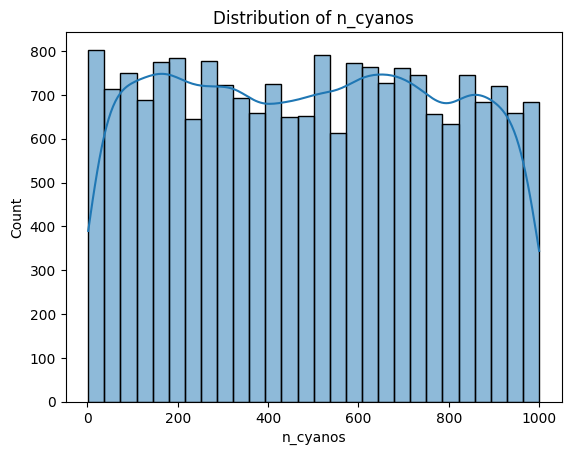

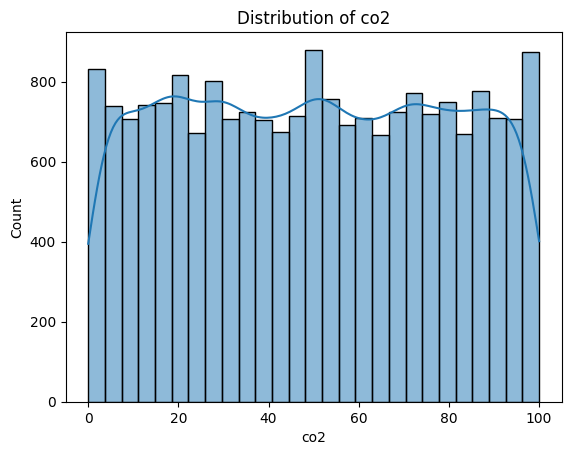

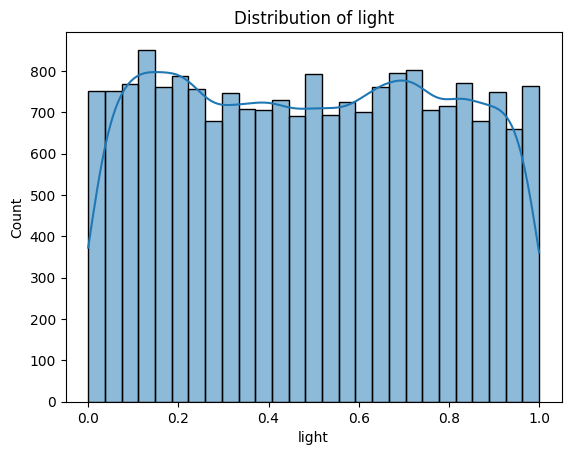

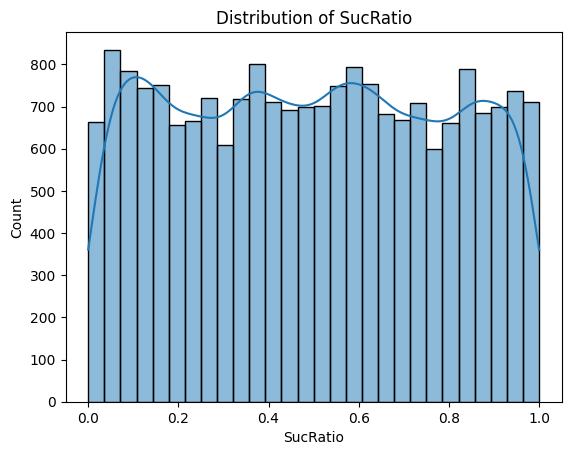

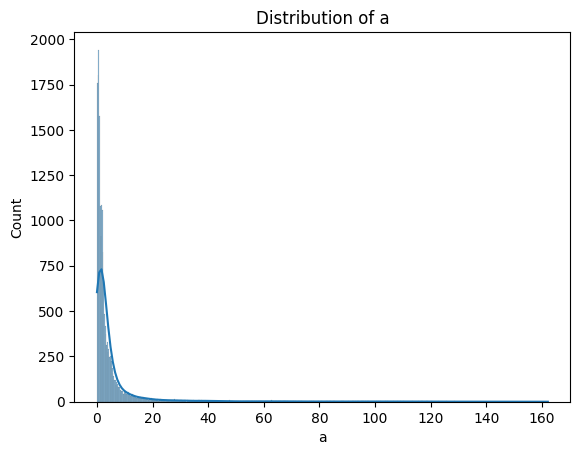

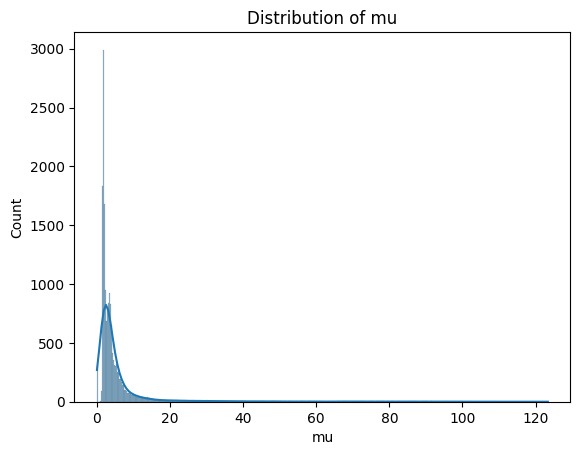

In [ ]:
features = ['n_cyanos', 'co2', 'light', 'SucRatio', 'a', 'mu']
for feature in features:
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

After analysing the pairwise scatterplot, several linear and inverse linear relationships are observed between the predictors and target variables 'a' and 'mu'. From the scatterplot between predictor variables, there seems to be no correlation between them which we will verfiy using correlation matrix later.

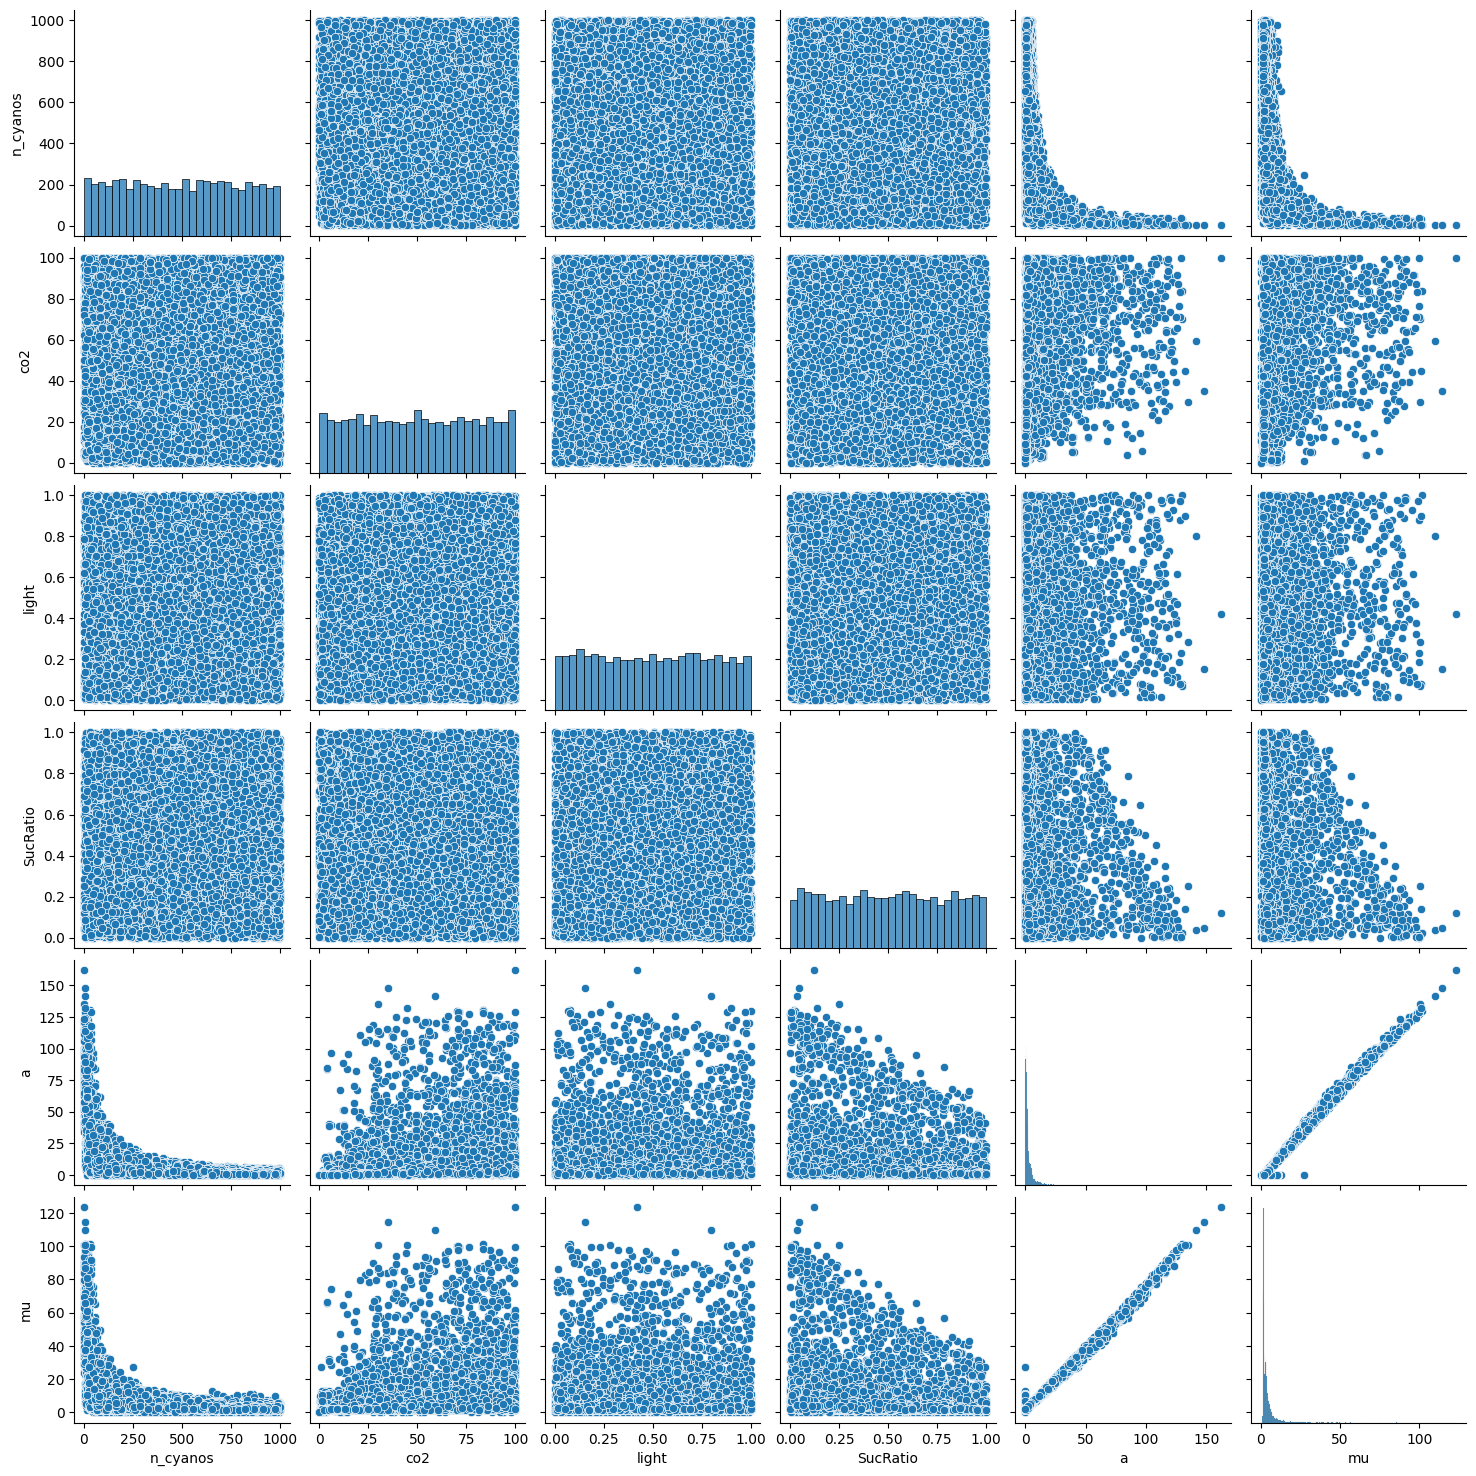

In [ ]:
sns.pairplot(df, vars=['n_cyanos', 'co2', 'light', 'SucRatio', 'a', 'mu'])
plt.show()

Since all of the predictor are numeric and have different ranges, we are normalizing the predictor variables so that while traning regression models we don't place higher importances to certain variables.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select features to scale
features_to_scale = ['n_cyanos', 'co2', 'light', 'SucRatio']
scaler = StandardScaler()

# Normalize the features
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

From the correlation matrix, there is no obvious multicollinearity between the predictor variables. So no Principle Component Analysis transformation is required.

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
          n_cyanos       co2     light  SucRatio   Nsample         a        mu
n_cyanos  1.000000  0.001203 -0.023443  0.006291  0.012220 -0.444273 -0.442704
co2       0.001203  1.000000 -0.002829  0.000193  0.009453  0.209350  0.209381
light    -0.023443 -0.002829  1.000000 -0.015138 -0.029933  0.008905  0.011367
SucRatio  0.006291  0.000193 -0.015138  1.000000 -0.004495 -0.195975 -0.231578
Nsample   0.012220  0.009453 -0.029933 -0.004495  1.000000 -0.004175 -0.003562
a        -0.444273  0.209350  0.008905 -0.195975 -0.004175  1.000000  0.996551
mu       -0.442704  0.209381  0.011367 -0.231578 -0.003562  0.996551  1.000000


Using the inter quartile variable technique, we are filtering out potential outliers in our dataset.

In [ ]:
#Finding outliers
# Step 1: Detect and remove outliers using IQR method
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Filtering out outliers (values outside 1.5 * IQR)
df_filtered = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
df_filtered.shape

(17699, 7)

Since N_samples is just the unique identifier of samples, it is excluded from the features. Next, although we are selecting light feature, we might want to exclude it later on as it shows very weak corelation with the target variables of transformed 'a' and 'mu'.

In [ ]:
# Features for predicting 'a'
X_a = df_filtered[['n_cyanos', 'co2', 'light', 'SucRatio']]
y_a = df_filtered['a']

# Features for predicting 'mu'
X_mu = df_filtered[['n_cyanos', 'co2', 'light', 'SucRatio']]
y_mu = df_filtered['mu']

Next we split the dataset into 70% traning and 30% testing set.

In [ ]:
from sklearn.model_selection import train_test_split

# For 'a'
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(X_a, y_a, test_size=0.3, random_state=42)

# For 'mu'
X_mu_train, X_mu_test, y_mu_train, y_mu_test = train_test_split(X_mu, y_mu, test_size=0.4, random_state=42)

Next we fit the linear regression model for both target variables 'a' and 'mu' using features such as 'n_cyanos', 'co2', 'SucRatio' and 'light'

*   We observed that the Training adjusted R squared value for a is 0.68 and Testing adjusted R squared value for a is 0.69 and Training adjusted R squared value for mu is 0.64 and Testing adjusted R squared value for mu is 0.64.
*   The R squared value for both 'a' and 'mu' which tells us that the linear regression models are not good at explaining the variability within the dataset.



In [ ]:
# Initialize linear regression model
model_a = LinearRegression()
model_mu = LinearRegression()

# Fit the model for target 'a'
model_a.fit(X_a_train, y_a_train)

# Fit the model for target 'mu'
model_mu.fit(X_mu_train, y_mu_train)
# Calculate Performance Metrics
# Predict on the training and testing sets for target 'a'
y_a_train_pred = model_a.predict(X_a_train)
y_a_test_pred = model_a.predict(X_a_test)

# Predict on the training and testing sets for target 'mu'
y_mu_train_pred = model_mu.predict(X_mu_train)
y_mu_test_pred = model_mu.predict(X_mu_test)

# Calculate metrics for target 'a'
rmse_a_train = np.sqrt(mean_squared_error(y_a_train, y_a_train_pred))
rmse_a_test = np.sqrt(mean_squared_error(y_a_test, y_a_test_pred))
r_squared_a_train = r2_score(y_a_train, y_a_train_pred)
r_squared_a_test = r2_score(y_a_test, y_a_test_pred)
adj_r_squared_a_train = 1 - (1 - r_squared_a_train) * (len(y_a_train) - 1) / (len(y_a_train) - X_a_train.shape[1] - 1)
adj_r_squared_a_test = 1 - (1 - r_squared_a_test) * (len(y_a_test) - 1) / (len(y_a_test) - X_a_test.shape[1] - 1)
print(f"Training R squared value for a: {r_squared_a_train}")
print(f"Testing R squared value for a:{r_squared_a_test}")
print(f"Training adjusted R squared value for a:{adj_r_squared_a_train}")
print(f"Testing adjusted R squared value for a:{adj_r_squared_a_test}")

print("")
print("")
# Calculate metrics for target 'mu'
rmse_mu_train = np.sqrt(mean_squared_error(y_mu_train, y_mu_train_pred))
rmse_mu_test = np.sqrt(mean_squared_error(y_mu_test, y_mu_test_pred))
r_squared_mu_train = r2_score(y_mu_train, y_mu_train_pred)
r_squared_mu_test = r2_score(y_mu_test, y_mu_test_pred)
adj_r_squared_mu_train = 1 - (1 - r_squared_mu_train) * (len(y_mu_train) - 1) / (len(y_mu_train) - X_mu_train.shape[1] - 1)
adj_r_squared_mu_test = 1 - (1 - r_squared_mu_test) * (len(y_mu_test) - 1) / (len(y_mu_test) - X_mu_test.shape[1] - 1)
print(f"Training R squared value for mu: {r_squared_mu_train}")
print(f"Testing R squared value for mu:{r_squared_mu_test}")
print(f"Training adjusted R squared value for mu:{adj_r_squared_mu_train}")
print(f"Testing adjusted R squared valuefor mu:{adj_r_squared_mu_test}")

Training R squared value for a: 0.6841625110013464
Testing R squared value for a:0.6902358978591192
Training adjusted R squared value for a:0.6840604963085173
Testing adjusted R squared value for a:0.6900023339743759


Training R squared value for mu: 0.6476402017994156
Testing R squared value for mu:0.6485848683173965
Training adjusted R squared value for mu:0.6475074112216125
Testing adjusted R squared valuefor mu:0.6483861883842897


Next, we perform recursive feature elimination to select those features that are most relevant in predicting the target variables, we found that the feature light has a weak linear relationship with both target variables and can be dropped from our features set.

In [ ]:
# RFE for target 'a'
selector_a = RFE(model_a, n_features_to_select=3)  # Select the top 3 features
selector_a = selector_a.fit(X_a_train, y_a_train)
selected_features_a = X_a.columns[selector_a.support_]
print(f"Selected features for linear regression model of a : {selected_features_a}")
# RFE for target 'mu'
selector_mu = RFE(model_mu, n_features_to_select=3)  # Select the top 3 features
selector_mu = selector_mu.fit(X_mu_train, y_mu_train)
selected_features_mu = X_mu.columns[selector_mu.support_]
print(f"Selected features for linear regression model of mu : {selected_features_mu}")

Selected features for linear regression model of a : Index(['n_cyanos', 'co2', 'SucRatio'], dtype='object')
Selected features for linear regression model of mu : Index(['n_cyanos', 'co2', 'SucRatio'], dtype='object')


Next we fit the linear regression model for both target variables 'a' and 'mu' after removing feature 'light'.

* We observed that the Training adjusted R squared value for a is 0.68 and Testing adjusted R squared value for a is 0.69 and Training adjusted R squared value for mu is 0.64 and Testing adjusted R squared value for mu is 0.64.
*   The same R squared values after eliminating light feature proves that dropping light was right decision.


In [ ]:
#Repeating linear regression by dropping light feature
model_a = LinearRegression()
model_mu = LinearRegression()

# Fit the model for target 'a'
model_a.fit(X_a_train.drop(columns=['light']), y_a_train)

# Fit the model for target 'mu'
model_mu.fit(X_mu_train.drop(columns=['light']), y_mu_train)
# Calculate Performance Metrics
# Predict on the training and testing sets for target 'a'
y_a_train_pred = model_a.predict(X_a_train.drop(columns=['light']))
y_a_test_pred = model_a.predict(X_a_test.drop(columns=['light']))

# Predict on the training and testing sets for target 'mu'
y_mu_train_pred = model_mu.predict(X_mu_train.drop(columns=['light']))
y_mu_test_pred = model_mu.predict(X_mu_test.drop(columns=['light']))

# Calculate metrics for target 'a'
rmse_a_train = np.sqrt(mean_squared_error(y_a_train, y_a_train_pred))
rmse_a_test = np.sqrt(mean_squared_error(y_a_test, y_a_test_pred))
r_squared_a_train = r2_score(y_a_train, y_a_train_pred)
r_squared_a_test = r2_score(y_a_test, y_a_test_pred)
adj_r_squared_a_train = 1 - (1 - r_squared_a_train) * (len(y_a_train) - 1) / (len(y_a_train) - X_a_train.drop(columns=['light']).shape[1] - 1)
adj_r_squared_a_test = 1 - (1 - r_squared_a_test) * (len(y_a_test) - 1) / (len(y_a_test) - X_a_test.drop(columns=['light']).shape[1] - 1)
print(f"Training R squared value for a: {r_squared_a_train}")
print(f"Testing R squared value for a:{r_squared_a_test}")
print(f"Training adjusted R squared value for a:{adj_r_squared_a_train}")
print(f"Testing adjusted R squared value for a:{adj_r_squared_a_test}")

print("")
print("")
# Calculate metrics for target 'mu'
rmse_mu_train = np.sqrt(mean_squared_error(y_mu_train, y_mu_train_pred))
rmse_mu_test = np.sqrt(mean_squared_error(y_mu_test, y_mu_test_pred))
r_squared_mu_train = r2_score(y_mu_train, y_mu_train_pred)
r_squared_mu_test = r2_score(y_mu_test, y_mu_test_pred)
adj_r_squared_mu_train = 1 - (1 - r_squared_mu_train) * (len(y_mu_train) - 1) / (len(y_mu_train) - X_mu_train.drop(columns=['light']).shape[1] - 1)
adj_r_squared_mu_test = 1 - (1 - r_squared_mu_test) * (len(y_mu_test) - 1) / (len(y_mu_test) - X_mu_test.drop(columns=['light']).shape[1] - 1)
print(f"Training R squared value for mu: {r_squared_mu_train}")
print(f"Testing R squared value for mu:{r_squared_mu_test}")
print(f"Training adjusted R squared value for mu:{adj_r_squared_mu_train}")
print(f"Testing adjusted R squared valuefor mu:{adj_r_squared_mu_test}")


Training R squared value for a: 0.6839674361184402
Testing R squared value for a:0.6904634221538187
Training adjusted R squared value for a:0.6838908840238384
Testing adjusted R squared value for a:0.6902884108960844


Training R squared value for mu: 0.6470702108236253
Testing R squared value for mu:0.6488853781345877
Training adjusted R squared value for mu:0.646970466182313
Testing adjusted R squared valuefor mu:0.6487365166499076


Next, we perform Residual Analysis by looking at residual plots, to check the assumptions of homoscedasticity (constant variance), normal distribution of residuals. Earlier, we verified linear relationship between independent and target variable, no multicollinearity between independent variables. We find that the residuals do not follow constant variance. The Q-Q plot of residuals for both 'a' and 'mu' shows skewed and heavy tails. we need to perform transformations to fix the two non conforming assumptions.

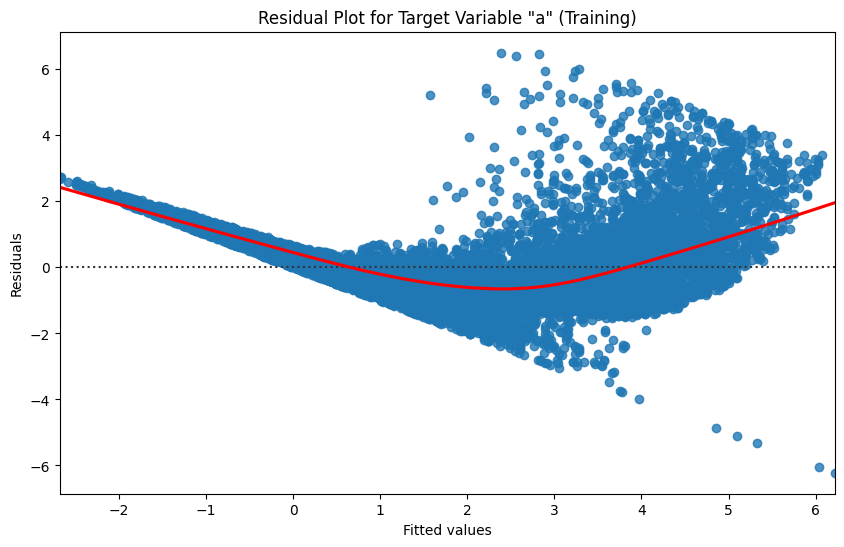

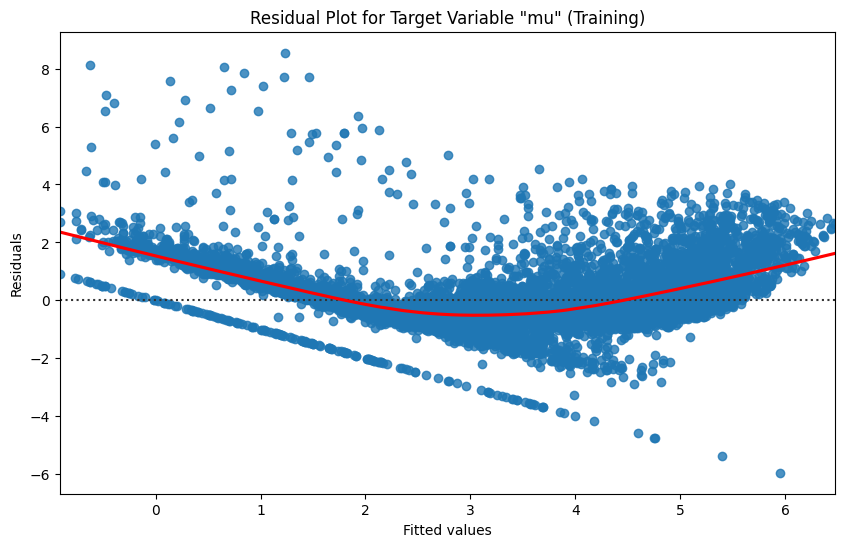

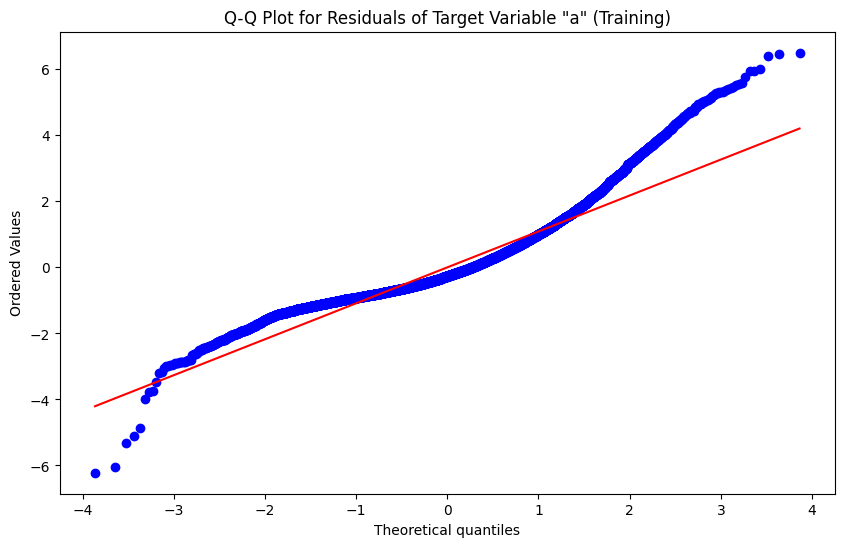

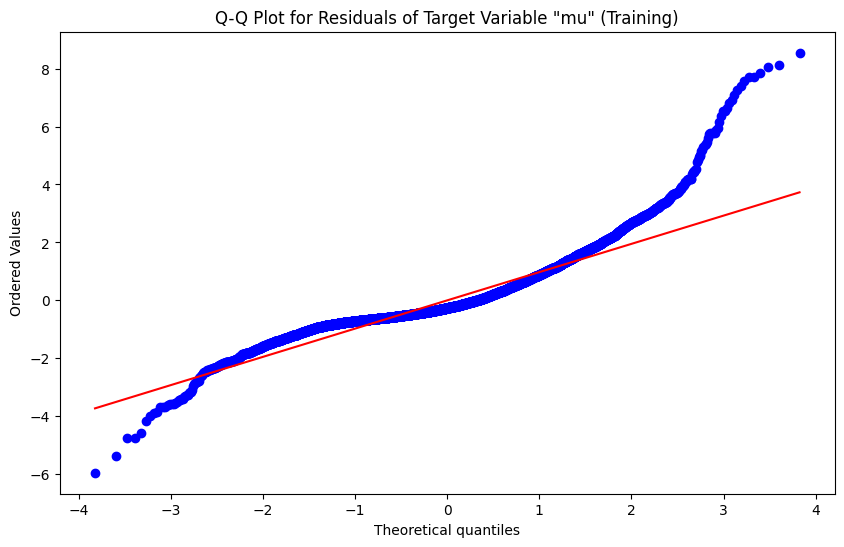

In [ ]:
#Residual Analysis
# Residuals for target 'a'
residuals_a_train = y_a_train - y_a_train_pred


# Residuals for target 'mu'
residuals_mu_train = y_mu_train - y_mu_train_pred


# Residual plot for 'a' (Training Data)
plt.figure(figsize=(10, 6))
sns.residplot(x=y_a_train_pred, y=residuals_a_train, lowess=True, line_kws={'color': 'red'})
plt.title('Residual Plot for Target Variable "a" (Training)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

# Residual plot for 'mu' (Training Data)
plt.figure(figsize=(10, 6))
sns.residplot(x=y_mu_train_pred, y=residuals_mu_train, lowess=True, line_kws={'color': 'red'})
plt.title('Residual Plot for Target Variable "mu" (Training)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

import scipy.stats as stats

# Q-Q Plot for residuals of target 'a'
plt.figure(figsize=(10, 6))
stats.probplot(residuals_a_train, dist="norm", plot=plt)
plt.title('Q-Q Plot for Residuals of Target Variable "a" (Training)')
plt.show()

# Q-Q Plot for residuals of target 'mu'
plt.figure(figsize=(10, 6))
stats.probplot(residuals_mu_train, dist="norm", plot=plt)
plt.title('Q-Q Plot for Residuals of Target Variable "mu" (Training)')
plt.show()


After applying box cox transormation to both target variables, we found that it reduced non constant variance of the residuals for both target variable. It also improves the normality of residuals as evident from Q-Q plots.

<ipython-input-40-9d2c0366c6fe>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['a_boxcox'] = a_boxcox
<ipython-input-40-9d2c0366c6fe>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['mu_boxcox'] = mu_boxcox


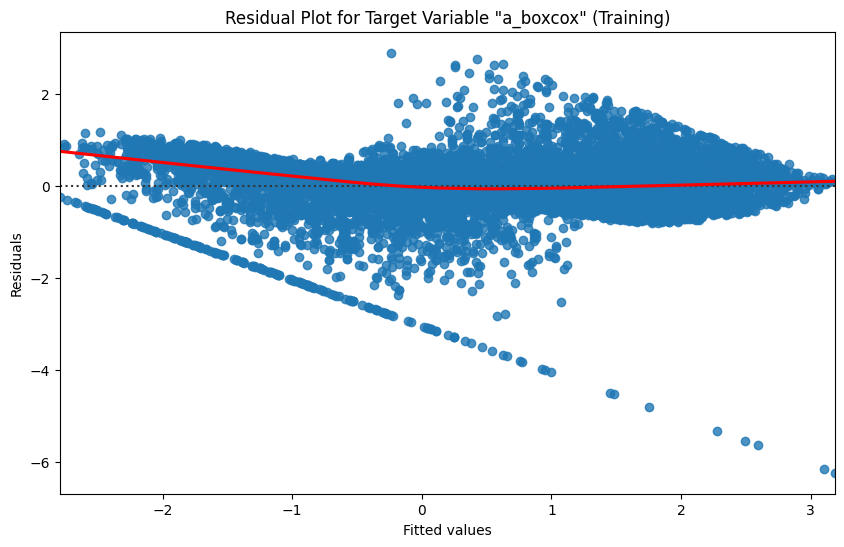

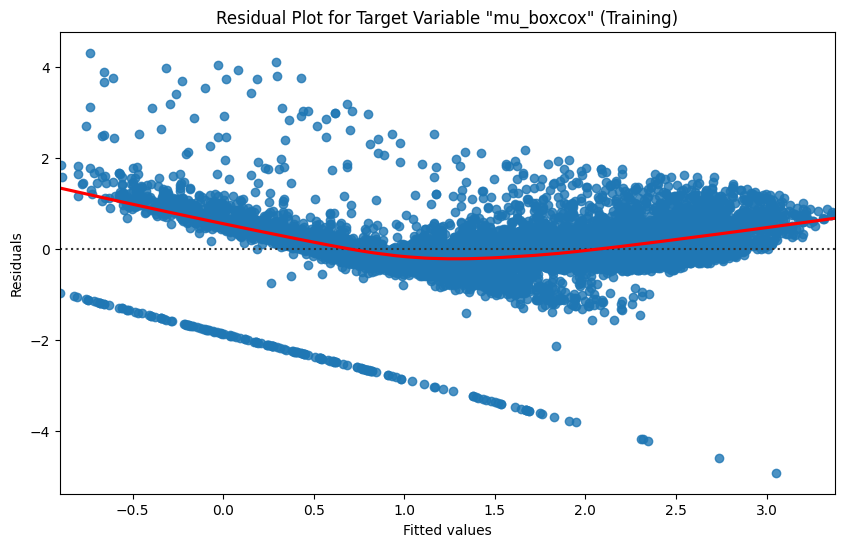

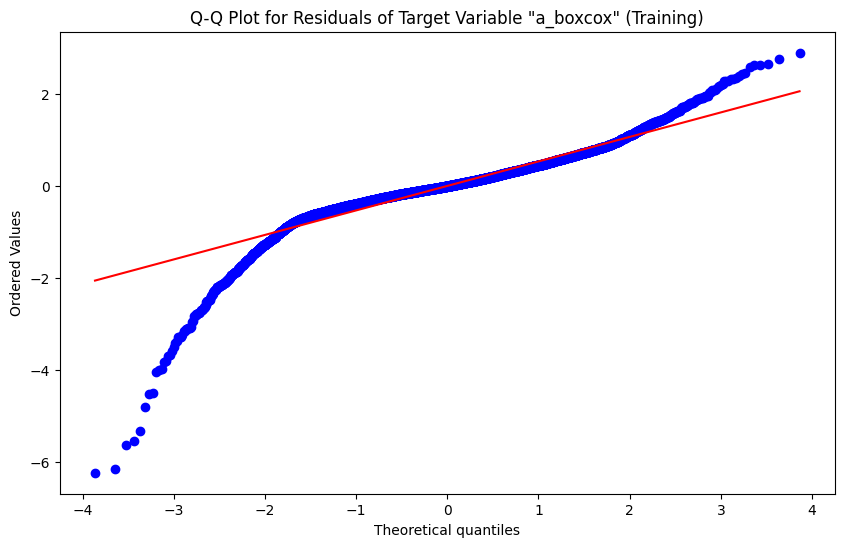

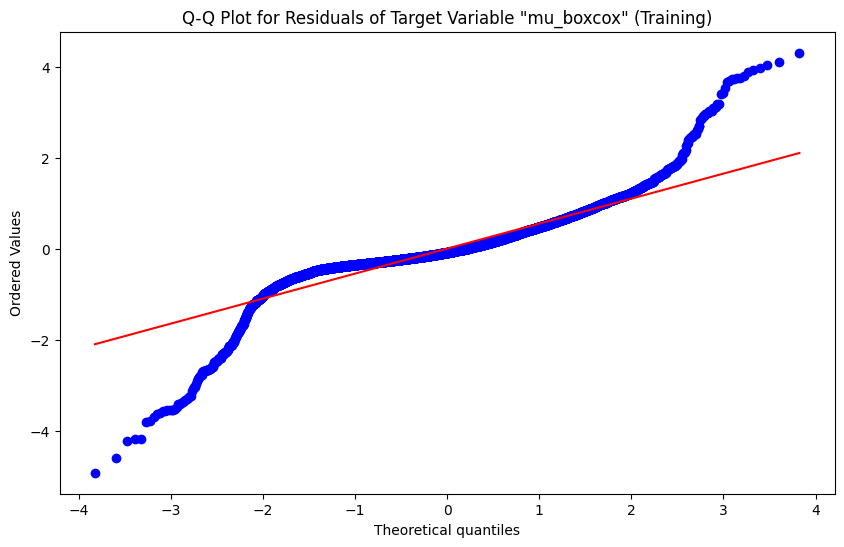

In [ ]:
# Apply Box-Cox transformation to a and mu and repeat Linear regression
from scipy.stats import boxcox, probplot

a_boxcox, lambda_a = boxcox(df_filtered['a'])
mu_boxcox, lambda_mu = boxcox(df_filtered['mu'])
df_filtered['a_boxcox'] = a_boxcox
df_filtered['mu_boxcox'] = mu_boxcox

# Features for predicting 'a'
X_a = df_filtered[['n_cyanos', 'co2','SucRatio']]
y_a = df_filtered['a_boxcox']

# Features for predicting 'mu'
X_mu = df_filtered[['n_cyanos', 'co2','SucRatio']]
y_mu = df_filtered['mu_boxcox']

# For 'a'
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(X_a, y_a, test_size=0.3, random_state=42)


# For 'mu'
X_mu_train, X_mu_test, y_mu_train, y_mu_test = train_test_split(X_mu, y_mu, test_size=0.4, random_state=42)

# Initialize linear regression model
model_a = LinearRegression()
model_mu = LinearRegression()

# Fit the model for target 'a'
model_a.fit(X_a_train, y_a_train)

# Fit the model for target 'mu'
model_mu.fit(X_mu_train, y_mu_train)
# Calculate Performance Metrics
# Predict on the training and testing sets for target 'a'
y_a_train_pred = model_a.predict(X_a_train)
y_a_test_pred = model_a.predict(X_a_test)

# Predict on the training and testing sets for target 'mu'
y_mu_train_pred = model_mu.predict(X_mu_train)
y_mu_test_pred = model_mu.predict(X_mu_test)

# Residuals for target 'a'
residuals_a_train = y_a_train - y_a_train_pred


# Residuals for target 'mu'
residuals_mu_train = y_mu_train - y_mu_train_pred


# Residual plot for 'a' (Training Data)
plt.figure(figsize=(10, 6))
sns.residplot(x=y_a_train_pred, y=residuals_a_train, lowess=True, line_kws={'color': 'red'})
plt.title('Residual Plot for Target Variable "a_boxcox" (Training)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

# Residual plot for 'mu' (Training Data)
plt.figure(figsize=(10, 6))
sns.residplot(x=y_mu_train_pred, y=residuals_mu_train, lowess=True, line_kws={'color': 'red'})
plt.title('Residual Plot for Target Variable "mu_boxcox" (Training)')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

import scipy.stats as stats

# Q-Q Plot for residuals of target 'a'
plt.figure(figsize=(10, 6))
stats.probplot(residuals_a_train, dist="norm", plot=plt)
plt.title('Q-Q Plot for Residuals of Target Variable "a_boxcox" (Training)')
plt.show()

# Q-Q Plot for residuals of target 'mu'
plt.figure(figsize=(10, 6))
stats.probplot(residuals_mu_train, dist="norm", plot=plt)
plt.title('Q-Q Plot for Residuals of Target Variable "mu_boxcox" (Training)')
plt.show()

After performing boxcox transormation to both 'a' and 'mu', we noticed an improvement in R squared values of 'a'. We observed that the Training adjusted R squared value for a is 0.80 and Testing adjusted R squared value for a is 0.80 and Training adjusted R squared value for mu is 0.65 and Testing adjusted R squared value for mu is 0.64. The R squared value for 'a' is pretty good, however the R squared value for 'mu' is still poor.

In [ ]:
#Performance metrics

# Calculate metrics for target 'a_boxocox'
print("Metrics for 'a_boxocox'")
print("")
rmse_a_train = np.sqrt(mean_squared_error(y_a_train, y_a_train_pred))
rmse_a_test = np.sqrt(mean_squared_error(y_a_test, y_a_test_pred))
r_squared_a_train = r2_score(y_a_train, y_a_train_pred)
r_squared_a_test = r2_score(y_a_test, y_a_test_pred)
adj_r_squared_a_train = 1 - (1 - r_squared_a_train) * (len(y_a_train) - 1) / (len(y_a_train) - X_a_train.shape[1] - 1)
adj_r_squared_a_test = 1 - (1 - r_squared_a_test) * (len(y_a_test) - 1) / (len(y_a_test) - X_a_test.shape[1] - 1)
print(f"Training R squared value for a_boxocox: {r_squared_a_train}")
print(f"Testing R squared value for a_boxocox:{r_squared_a_test}")
print("")
print(f"Training adjusted R squared value for a_boxocox:{adj_r_squared_a_train}")
print(f"Testing adjusted R squared value for a_boxocox:{adj_r_squared_a_test}")
print("")
print(f"Training RMSE for a_boxcox: {rmse_a_train}")
print(f"Testing RMSE for a_boxcox: {rmse_a_test}")
print("")
print("")
print("")
# Calculate metrics for target 'mu_boxcox'
print("Metrics for 'mu_boxcox'")
print("")
rmse_mu_train = np.sqrt(mean_squared_error(y_mu_train, y_mu_train_pred))
rmse_mu_test = np.sqrt(mean_squared_error(y_mu_test, y_mu_test_pred))
r_squared_mu_train = r2_score(y_mu_train, y_mu_train_pred)
r_squared_mu_test = r2_score(y_mu_test, y_mu_test_pred)
adj_r_squared_mu_train = 1 - (1 - r_squared_mu_train) * (len(y_mu_train) - 1) / (len(y_mu_train) - X_mu_train.shape[1] - 1)
adj_r_squared_mu_test = 1 - (1 - r_squared_mu_test) * (len(y_mu_test) - 1) / (len(y_mu_test) - X_mu_test.shape[1] - 1)
print(f"Training R squared value for mu_boxcox: {r_squared_mu_train}")
print(f"Testing R squared value for mu_boxcox:{r_squared_mu_test}")
print("")
print(f"Training adjusted R squared value for mu_boxcox:{adj_r_squared_mu_train}")
print(f"Testing adjusted R squared valuefor mu_boxcox:{adj_r_squared_mu_test}")
print("")
print(f"Training RMSE for mu_boxcox: {rmse_mu_train}")
print(f"Testing RMSE for mu_boxcox: {rmse_mu_test}")



Metrics for 'a_boxocox'

Training R squared value for a_boxocox: 0.8047302870055439
Testing R squared value for a_boxocox:0.8078247066050304

Training adjusted R squared value for a_boxocox:0.8046829871154363
Testing adjusted R squared value for a_boxocox:0.8077160511432541

Training RMSE for a_boxcox: 0.5613079299638405
Testing RMSE for a_boxcox: 0.5587491586119766



Metrics for 'mu_boxcox'

Training R squared value for mu_boxcox: 0.6505552647620092
Testing R squared value for mu_boxcox:0.6443179238378911

Training adjusted R squared value for mu_boxcox:0.6504565050629312
Testing adjusted R squared valuefor mu_boxcox:0.644167125897178

Training RMSE for mu_boxcox: 0.5930644692664916
Testing RMSE for mu_boxcox: 0.6033827470621387


Next, we fit a decision tree regressor model to the traninig dataset for both target variables 'a' and 'mu'. We selected max_depth = 5, min_samples_split=10, min_samples_leaf=5 for 'a', similarly max_depth = 6, min_samples_split=10, min_samples_leaf=5 for 'mu' because the default parameters would fit the decsion tree perfectly on the training data set resulting in R squared value of 1 which is an obviuos case for overfitting. After setting the aforementioned parameters, we found traning R squared value of 0.85 and testing R squared value of 0.83 for target variable 'a'. Similarly, we found traning R squared value of 0.82 and testing R squared value of 0.78 for target variable 'mu'. This decison tree was not hypertuned, so we will try to hypertune the parameters in the next section.

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
# Decision Tree for 'a'

# Initialize the Decision Tree regressor model for a
decision_tree = DecisionTreeRegressor(random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5)

# Fit the model
decision_tree.fit(X_a_train, y_a_train)

# Predict on the train and test set
y_a_train_pred = decision_tree.predict(X_a_train)
y_a_test_pred = decision_tree.predict(X_a_test)

# Performance evaluation

# Accuracy score
# Compute mse
mse_a = mean_squared_error(y_a_test, y_a_test_pred)
# Compute rmse
rmse_a = mse_a**(1/2)
# Compute R-squared for train and test sets
r2_train_a = r2_score(y_a_train, y_a_train_pred)
r2_test_a = r2_score(y_a_test, y_a_test_pred)

print('Decision Tree train set R^2 for a: {:.2f}'.format(r2_train_a))
print('Decision Tree test set R^2 for a: {:.2f}'.format(r2_test_a))
print('Regression Tree test set RMSE for a: {:.2f}'.format(rmse_a))

# Initialize the Decision Tree regressor model for mu
decision_tree1 = DecisionTreeRegressor(random_state=42,
                                       max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5)

# Fit the model
decision_tree1.fit(X_mu_train, y_mu_train)

# Predict on the train and test set
y_mu_train_pred = decision_tree1.predict(X_mu_train)
y_mu_test_pred = decision_tree1.predict(X_mu_test)

# Performance evaluation

# Accuracy score
# Compute mse
mse_mu = mean_squared_error(y_mu_test, y_mu_test_pred)
# Compute rmse
rmse_mu = mse_mu**(1/2)
# Compute R-squared for train and test sets
r2_train_mu = r2_score(y_mu_train, y_mu_train_pred)
r2_test_mu = r2_score(y_mu_test, y_mu_test_pred)
print("")
print("")

print('Decision Tree train set R^2 for mu: {:.2f}'.format(r2_train_mu))
print('Decision Tree test set R^2 for mu: {:.2f}'.format(r2_test_mu))
print('Regression Tree test set RMSE for mu: {:.2f}'.format(rmse_mu))

Decision Tree train set R^2 for a: 0.85
Decision Tree test set R^2 for a: 0.83
Regression Tree test set RMSE for a: 0.53


Decision Tree train set R^2 for mu: 0.82
Decision Tree test set R^2 for mu: 0.78
Regression Tree test set RMSE for mu: 0.47


After performing a grid search method to hypertune the parameters of the decision trees, we found traning R squared value of 0.98 and testing R squared value of 0.95 for target variable 'a'. Similarly, we found traning R squared value of 0.82 and testing R squared value of 0.78 for target variable 'mu'. For target variable 'a', we almost get a perfect R squared value on training set which shows that the tree tries to learn the entire dataset which is not good and hence we prefer a shorter tree which we selected earlier. Increasing the tree depth and increasing the minimum leaf nodes will always improve the prediction accuracy of tranining dataset but is not a wise choice as it will lead to overfitting and not help much on a unseen dataset like testing dataset. For target variable 'mu' we found similar R squared values to the model we fit without hypertuning, the R squared value for training dataset is 0.82 and testing dataset is 0.78.

In [ ]:
#Decison tree regression for a with hyper parameter tuning

import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
decision_tree2 = DecisionTreeRegressor(random_state=42)

# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=decision_tree2,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_a_train, y_a_train)

# Retrieve the best model
best_model = grid_search.best_estimator_

# Predictions
y_a_train_pred = best_model.predict(X_a_train)
y_a_test_pred = best_model.predict(X_a_test)

# Evaluate the best model
mse_a = mean_squared_error(y_a_test, y_a_test_pred)
rmse_a = mse_a**(1/2)
r2_train_a = r2_score(y_a_train, y_a_train_pred)
r2_test_a = r2_score(y_a_test, y_a_test_pred)


# Print results
print("Best Parameters:", grid_search.best_params_)
print('Best Decision Tree test set RMSE for a: {:.2f}'.format(rmse_a))
print('Best Decision Tree train set R^2 for a: {:.2f}'.format(r2_train_a))
print('Best Decision Tree test set R^2 for a: {:.2f}'.format(r2_test_a))

#Decison tree regression for a with hyper parameter tuning


decision_tree3 = DecisionTreeRegressor(random_state=42)

# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5,6, 10],
    'min_samples_leaf': [1, 2, 5,10],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=decision_tree3,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_mu_train, y_mu_train)

# Retrieve the best model
best_model = grid_search.best_estimator_

# Predictions
y_mu_train_pred = best_model.predict(X_mu_train)
y_mu_test_pred = best_model.predict(X_mu_test)

# Evaluate the best model
mse_mu = mean_squared_error(y_mu_test, y_mu_test_pred)
rmse_mu = mse_mu**(1/2)
r2_train_a = r2_score(y_mu_train, y_mu_train_pred)
r2_test_a = r2_score(y_mu_test, y_mu_test_pred)

print("")
print("")

# Print results
print("Best Parameters:", grid_search.best_params_)
print('Best Decision Tree test set RMSE for mu: {:.2f}'.format(rmse_mu))
print('Best Decision Tree train set R^2 for mu: {:.2f}'.format(r2_train_mu))
print('Best Decision Tree test set R^2 for mu: {:.2f}'.format(r2_test_mu))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Decision Tree test set RMSE for a: 0.28
Best Decision Tree train set R^2 for a: 0.98
Best Decision Tree test set R^2 for a: 0.95
Fitting 5 folds for each of 192 candidates, totalling 960 fits


Best Parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Decision Tree test set RMSE for mu: 0.37
Best Decision Tree train set R^2 for mu: 0.82
Best Decision Tree test set R^2 for mu: 0.78


Conclusion

We trained two models, a linear regression model and a decision tree regressor model, we found that the decision tree performs better than linear regression model in terms of R squared value for target variable 'mu' and performs similarly to linear regression for target variable 'a'. Eventually, we select the linear regression as our best model for 'a' which is because although the decision tree works equally well, it can prone to overfitting depending on the depth of the tree. For 'mu', we select the decision tree as the best model as it provides testing R squared value of 0.8 as compared to 0.64 with linear regression. There is an additional reason to reject linear regression model for 'mu which is although we applied box cox transformation, it didn't fix the non constant variance and normality of residuals as well as it did for 'a'. Without satisfying the linear regression model residual assumptions, it doesn't make sense that we use the linear regression model.

---
---
## Dataset 3: NLP

The  dataset contains texts from news articles.

The file contains just one feature - the news story, one per line.


Importing relevant libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from sklearn.decomposition import PCA
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from nltk import pos_tag
from nltk.chunk import ne_chunk

Downloading NLTK Resources

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

The dataset includes various news articles but with some missing data.

In [ ]:
data = pd.read_csv('news.csv', on_bad_lines='skip')
print(data)

Dropping the rows with missing data and fill and missing values with empty string.

In [ ]:
data.columns
print(data['story'].isnull().sum())
# Drop rows with missing text
data = data.dropna(subset=['story'])

# OR fill missing values with an empty string
data['story'] = data['story'].fillna('')

print(data['story'].apply(type).value_counts())
print(data)

1365
story
<class 'str'>    16
Name: count, dtype: int64
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

<ipython-input-53-457f28a52e77>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['story'] = data['story'].fillna('')


Now we preprocess the data by performing transformations (lowercase, removing special characters such as '...', numbers, punctuations).

In [ ]:
#Preprocess the Text
data['story'] = data['story'].astype(str)

# Convert text to lowercase
data['story'] = data['story'].str.lower()
print(data['story'])

# Remove special characters, numbers, and punctuation
data['cleaned_text'] = data['story'].str.replace(r'[^a-zA-Z\s]', '', regex=True)
data['cleaned_text'].isnull().sum(), data[data['cleaned_text'] == ''].shape[0]

# Replace ellipses with a space or a custom string (e.g., ' ellipsis ')
data['cleaned_text'] = data['cleaned_text'].str.replace(r'\.\.\.', ' ', regex=True)

# Remove rows with NaN or empty cleaned text
data = data.dropna(subset=['cleaned_text'])
data = data[data['cleaned_text'].str.strip() != '']
print(data['cleaned_text'])


# Tokenize the text (break text into words)
data['tokens'] = data['cleaned_text'].apply(word_tokenize)

# Remove stopwords
stop_words = set(stopwords.words('english'))
data['filtered_tokens'] = data['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   from $639m year-earlier.  The firm                                                                                                                                                                                                                                                      

Now, we calculate number of words and senctence in the dataset and also create a word cloud containing frequently used words.

       word_count  sentence_count
count   16.000000        16.00000
mean    16.125000         2.25000
std     22.165664         0.68313
min      2.000000         1.00000
25%      5.750000         2.00000
50%     10.000000         2.00000
75%     18.500000         2.25000
max     95.000000         4.00000


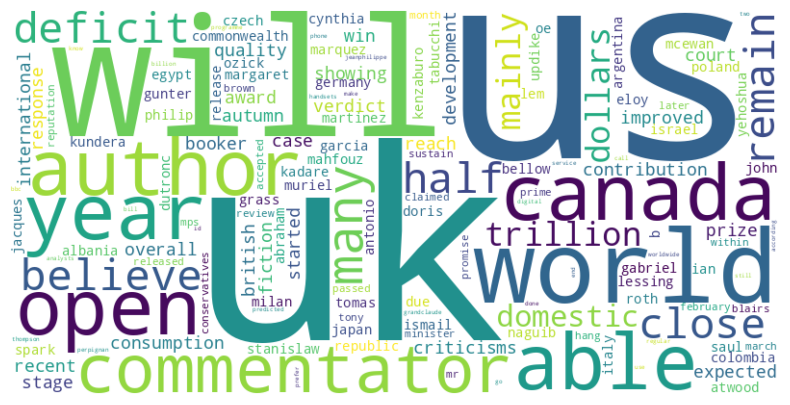

In [ ]:
# Analyze Text Data
data['word_count'] = data['cleaned_text'].apply(lambda x: len(x.split()))
data['sentence_count'] = data['story'].apply(lambda x: x.count('.') + 1)

# Basic statistics
print(data[['word_count', 'sentence_count']].describe())

# 3. **Frequent Words: Word Cloud and Top Words**
all_words = ' '.join(data['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Plot the Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Next, we transform the cleaned text data into matrix with 16 samples and 411 features, we also captured both single words and word pairs among possible 5000 features.

In [ ]:
#Text Vectorization with TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit and transform the cleaned text data
X_tfidf = tfidf_vectorizer.fit_transform(data['cleaned_text'])

# Check the shape of the transformed data
print(X_tfidf.shape)

(16, 411)


Next, we use LDA model to find out topics within the data. The model has found 5 different topics each containing set of words that frequently appear together.

In [ ]:
#LDA

from sklearn.decomposition import LatentDirichletAllocation

# Number of topics (you can experiment with this value)
n_topics = 5

# Fit the LDA model
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X_tfidf)

# Print out the top words for each topic
terms = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print(f"Topic {topic_idx}:")
    print([terms[i] for i in topic.argsort()[-10:]])  # Display top 10 words for each topic
    print()

Topic 0:
['and', 'in the', 'is', 'in', 'grandclaude', 'jeanphilippe', 'jeanphilippe grandclaude', 'perpignan', 'grandclaude perpignan', 'the']

Topic 1:
['have done', 'have', 'mr', 'mr brown', 'claimed', 'claimed mr', 'brown', 'jacques', 'dutronc', 'jacques dutronc']

Topic 2:
['on to', 'to that', 'will hang', 'hang on', 'hang', 'we', 'that', 'in', 'to', 'the']

Topic 3:
['that', 'in', 'for', 'due', 'due for', 'february', 'for release', 'in february', 'release', 'release in']

Topic 4:
['response to', 'lessing', 'lem poland', 'the', 'and', 'to', 'only', 'canada', 'us', 'uk']



Next, we assign most likely topic number to each article

In [ ]:
# Get the topic distribution for each article
topic_distribution = lda.transform(X_tfidf)

# Assign the most likely topic to each article
data['topic'] = topic_distribution.argmax(axis=1)

# Display the first few rows with assigned topics
print(data[['story', 'topic']].head())

Conclusion:

For this dataset which contains news article text, we performed EDA by finding most frequent words using word cloud which showed words like UK, US and will etc as most used words. There are total of 16 sentences, we found that most of the news article distributed in 5 topics to perform this EDA and transforming the text into machine learning readable format we had to perform preprocessing tokenization and lemmatization and perform LDA.